In [1]:
import io
import textwrap

import beaker
import cartopy.crs as ccrs
import faceted
import numpy as np
import pandas as pd
import wandb
import xarray as xr

import plotting

In [2]:
UNCOMBINED_CASES = {
    "ACE2-SHiELD": {
        1: "01KMGKXDBRAKFTDADM4B0A5Z2Q",
        2: "01KMGKWZVYAGDX7XXXX413DB65",
        3: "01KMGKWK1JTZX4FAG7E27V987B",
        4: "01KMGKW5K9P6RJ9F1D7NDMWFFT",
        5: "01KMGKVRVTCCFJHZCBNJM0RSXW",
    },
    "full energy-conserving rs0": {
        1: "01KMJM2H2GY1XSD5H89964S78W",
        2: "01KMJM1ZVEK30KNRJY8ZHAGF1B",
        3: "01KMJM1JA75FXW514AXPZXCQVS",
        4: "01KMJM143K911T34QP74VHFZAP",
        5: "01KMJM0PAF21SD8F82MXCXMKJ9",
    },
    "SHiELD": {
        1: "01KMGK3MDY5T575NKP62S09YYQ",
        2: "01KMGK3Y3TGY0S982MTE8ESA5H"
    }
}

In [3]:
TEST_PREFIX = "test"
TRAIN_VALIDATE_PREFIX = "train-and-validate"


def open_beaker_dataset(dataset_id: str, path: str) -> xr.Dataset:
    """Given a beaker dataset ID and path within dataset, return an xarray
    dataset.

    Note: dataset must fit in memory. Requires h5netcdf backend.  Adapted from
    ace2-paper repo.
    """
    client = beaker.Beaker.from_env()
    file = client.dataset.get_file(dataset_id, path)
    ds = xr.open_dataset(io.BytesIO(file), engine="h5netcdf").load()
    if "source" in ds.dims:
        ds = ds.sel(source="target").drop_vars("source")
    return ds


def open_uncombined_dataset(dataset_ids: dict[int, str], path: str) -> xr.Dataset:
    """Given a dictionary of dataset IDs and a path, return an xarray dataset.
    """
    return xr.concat([open_beaker_dataset(dataset_id, path) for dataset_id in dataset_ids.values()], dim=pd.Index(dataset_ids.keys(), name="sample"))


def open_uncombined_datasets(cases: dict[str, dict[int, str]], path: str) -> xr.Dataset:
    datasets = {}
    for case, dataset_ids in cases.items():
        datasets[case] = open_uncombined_dataset(dataset_ids, path)
    return xr.concat(datasets.values(), dim=pd.Index(cases.keys(), name="model"))


def open_datasets(uncombined_cases: dict[str, dict[int, str]], path: str) -> xr.Dataset:
    train_and_validate_ds = open_uncombined_datasets(uncombined_cases, f"{TRAIN_VALIDATE_PREFIX}/{path}")
    test_ds = open_uncombined_datasets(uncombined_cases, f"{TEST_PREFIX}/{path}")
    return xr.concat([train_and_validate_ds, test_ds], dim="year")


def open_uncombined_dataset_first_sample(uncombined_cases: dict[str, dict[int, str]], path: str) -> xr.Dataset:
    datasets = {}
    for case, dataset_ids in uncombined_cases.items():
        datasets[case] = open_uncombined_dataset(dataset_ids, path).isel(sample=0)
    return xr.concat(datasets.values(), dim=pd.Index(uncombined_cases.keys(), name="model"))

In [4]:
annual_ds = open_datasets(UNCOMBINED_CASES, "annual_diagnostics.nc")
mean_ds = open_uncombined_dataset_first_sample(UNCOMBINED_CASES, f"{TEST_PREFIX}/time_mean_diagnostics.nc")
mean_bias = mean_ds.drop_sel(model="SHiELD") - mean_ds.sel(model="SHiELD")

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget: 01HPM52AQCRXMD5BPZAMJG3TDZ' for data model 'Workspace'. This may be a newly added field that hasn't been defined in beaker-py yet. Please submit an issue report about this here:
https://github.com/allenai/beaker-py/issues/new?assignees=&labels=bug&template=bug_report.yml
  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/client.py:163: UserWarning: You're using beaker-py v1.32.2, but a newer version (v1.38.1) is available.

Please upgrade with `pip install --upgrade beaker-py`.

You can find the release notes for v1.38.1 at https://github.com/allenai/beaker-py/releases/tag/v1.38.1

  warnings.warn(
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/beaker/util.py:25: RuntimeWarning: Found unknown field 'budget:

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

Output()

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/hom

<Axes: xlabel='model'>

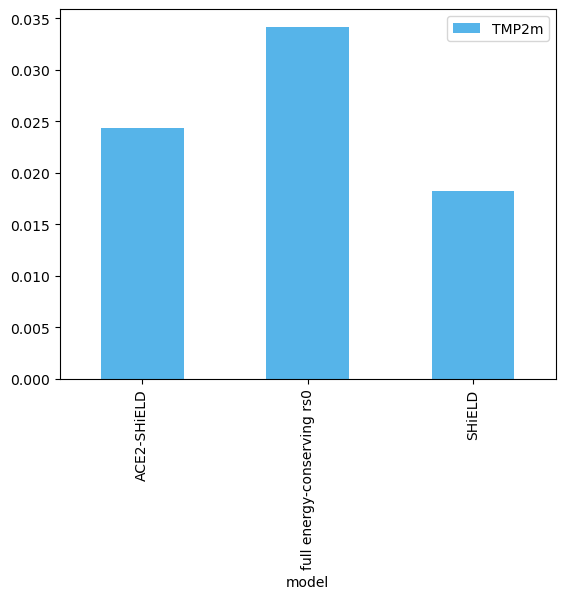

In [8]:
annual_ds.std("sample").mean("year").TMP2m.to_dataframe().plot.bar()

/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/spencerc/ace2s-shield-plus-paper/manuscript/.pixi/envs/default/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/hom

<Axes: xlabel='model'>

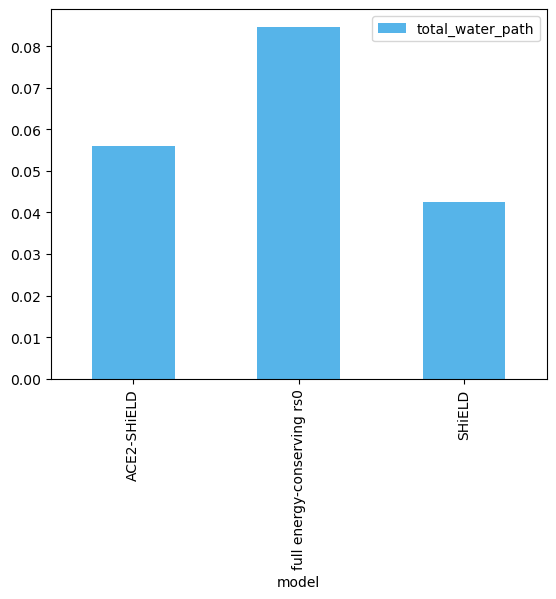

In [9]:
annual_ds.std("sample").mean("year").total_water_path.to_dataframe().plot.bar()

In [10]:
ss_residual = ((annual_ds - annual_ds.sel(model="SHiELD", sample=1)) ** 2).sum("year")
ss_total = ((annual_ds - annual_ds.mean("year")) ** 2).sum("year")
r2 = 1.0 - (ss_residual / ss_total)

In [11]:
r2.TMP2m.min("sample")

<xarray.DataArray 'TMP2m' (model: 3)> Size: 12B
array([0.85796475, 0.8066344 , 0.95901793], dtype=float32)
Coordinates:
  * model    (model) StringDType(na_object=nan) 48B 'ACE2-SHiELD' ... 'SHiELD'

In [12]:
r2.TMP2m.max("sample")

<xarray.DataArray 'TMP2m' (model: 3)> Size: 12B
array([0.87727296, 0.9325148 , 1.        ], dtype=float32)
Coordinates:
  * model    (model) StringDType(na_object=nan) 48B 'ACE2-SHiELD' ... 'SHiELD'

In [13]:
r2.total_water_path.min("sample")

<xarray.DataArray 'total_water_path' (model: 3)> Size: 12B
array([0.78048754, 0.8224292 , 0.93816173], dtype=float32)
Coordinates:
  * model    (model) StringDType(na_object=nan) 48B 'ACE2-SHiELD' ... 'SHiELD'

In [14]:
r2.total_water_path.max("sample")

<xarray.DataArray 'total_water_path' (model: 3)> Size: 12B
array([0.82356495, 0.94688857, 1.        ], dtype=float32)
Coordinates:
  * model    (model) StringDType(na_object=nan) 48B 'ACE2-SHiELD' ... 'SHiELD'

In [15]:
TITLE_TEMPLATE = """{name}
Global {metric_name} = {g:0.2f}
Land {metric_name} = {l:0.2f}
Ocean/sea-ice {metric_name} = {n:0.2f}"""

NO_NAME_TITLE_TEMPLATE = """Global {metric_name} = {g:0.2f}
Land {metric_name} = {l:0.2f}
Ocean/sea-ice {metric_name} = {n:0.2f}"""


def get_land_fraction(grid: str = "gaussian_grid_180_by_360") -> xr.DataArray:
    # Note the land fraction may not be identical on the coastlines for the C96
    # and C24 data regridded to a 4 degree Gaussian grid.  We have not paid
    # that close attention to non-global averages up to this point though, so
    # for now we will not worry about this detail.
    rename = {
        "grid_xt": "lon",
        "grid_yt": "lat",
        "grid_xt_bnds": "lon_bnds",
        "grid_yt_bnds": "lat_bnds",
    }
    ds = xr.open_zarr(
        f"gs://vcm-ml-raw-flexible-retention/2024-06-29-C96-SHiELD-AMIP/regridded-zarrs/{grid}/ic_0001/full_state.zarr"
    )
    ds = ds.rename(rename)
    return ds.isel(time=0).land_fraction.drop_vars("time")


def get_weights(grid: str = "gaussian_grid_180_by_360") -> xr.Dataset:
    land_fraction = get_land_fraction(grid)
    non_land_fraction = 1 - land_fraction
    area_weights = np.cos(np.deg2rad(land_fraction.lat)).broadcast_like(land_fraction)
    return (
        xr.concat(
            [
                area_weights,
                area_weights * land_fraction,
                area_weights * non_land_fraction,
            ],
            dim=pd.Index(["global", "land", "non-land"], name="region"),
        )
        .drop_vars(["lon", "lat"])
        .load()
    )


def get_title(metric, variable, model, metric_name):
    sel_kwargs = {"model": model}
    g = metric.sel(region="global", **sel_kwargs)[variable].item()
    l = metric.sel(region="land", **sel_kwargs)[variable].item()
    n = metric.sel(region="non-land", **sel_kwargs)[variable].item()
    return NO_NAME_TITLE_TEMPLATE.format(metric_name=metric_name, g=g, l=l, n=n)

In [16]:
weights = get_weights("gaussian_grid_180_by_360")
regional_mean_bias = mean_bias.weighted(weights).mean(["lat", "lon"]).compute()
rmse = np.sqrt((mean_bias ** 2).weighted(weights).mean(["lat", "lon"])).compute()

In [51]:
COLORS = {
    "SHiELD": "k",
    "ACE2-SHiELD": "C0",
    "full energy-conserving rs0": "C4",
}

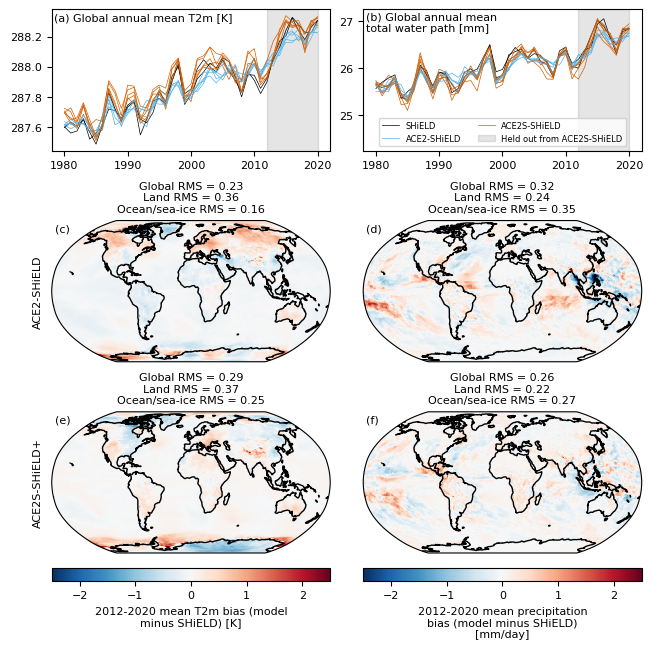

In [53]:
plotting.configure_style()

aspect = plotting.get_aspect_ratio(ccrs.Robinson(), (-180, 180, -89.84, 89.84))
fig, (ax5, ax6, ax3, ax4, ax1, ax2), (cax1, cax2) = plotting.width_constrained_plot(
    3,
    2,
    6.5,
    aspect,
    cbar_pad=0.15,
    horizontal_pads=[0.33],
    vertical_pads=[0.5, 0.7],
    left_pad=0.45,
    bottom_pad=0.7,
    top_pad=0.1,
    right_pad=0.15,
    axes_kwargs={"projection": ccrs.Robinson()},
)

# Remove projection from axes[0] and axes[1].
position = ax1.get_position(original=True)
ax1.set_visible(False)
ax1 = fig.add_axes(position)

position = ax2.get_position(original=True)
ax2.set_visible(False)
ax2 = fig.add_axes(position)

for sample in annual_ds.sample:
    if sample.item() == 1:
        label_shield = "SHiELD"
        label_ace2_shield = "ACE2-SHiELD"
        label_ace2s_shield = "ACE2S-SHiELD"
    else:
        label_shield = None
        label_ace2_shield = None
        label_ace2s_shield = None

    annual_ds.sel(
        model="SHiELD", sample=sample
    ).TMP2m.plot(ax=ax1, color=COLORS["SHiELD"], lw=0.5, label=label_shield)
    annual_ds.sel(
        model="ACE2-SHiELD", sample=sample
    ).TMP2m.plot(ax=ax1, color=COLORS["ACE2-SHiELD"], lw=0.5, label=label_ace2_shield)
    annual_ds.sel(
        model="full energy-conserving rs0", sample=sample
    ).TMP2m.plot(ax=ax1, color=COLORS["full energy-conserving rs0"], lw=0.5, label=label_ace2s_shield)

    annual_ds.sel(
        model="SHiELD", sample=sample
    ).total_water_path.plot(ax=ax2, color=COLORS["SHiELD"], lw=0.5, label=label_shield)
    annual_ds.sel(
        model="ACE2-SHiELD", sample=sample
    ).total_water_path.plot(ax=ax2, color=COLORS["ACE2-SHiELD"], lw=0.5, label=label_ace2_shield)
    annual_ds.sel(
        model="full energy-conserving rs0", sample=sample
    ).total_water_path.plot(ax=ax2, color=COLORS["full energy-conserving rs0"], lw=0.5, label=label_ace2s_shield)

ax1.set_title("")
ax2.set_title("")

for ax in (ax1, ax2):
    ax.set_xlabel("")
    ax.set_ylabel("")

ax1.annotate(
    "(a) Global annual mean T2m [K]",
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)
ax2.annotate(
    textwrap.fill("(b) Global annual mean total water path [mm]", width=25),
    xy=(0, 1),
    xytext=(2, -2),
    va="top",
    xycoords="axes fraction",
    textcoords="offset points",
)

for ax in (ax1, ax2):
    ax.axvspan(2012, 2020, color="k", alpha=0.1, label="Held out from ACE2S-SHiELD")

ax2.legend(ncol=2, fontsize=6, loc="lower center")
ax2.set_yticks([25, 26, 27])
ax2.set_ylim(24.25, 27.25)

vmin, vmax = -2.5, 2.5
cmap = "RdBu_r"
p1 = mean_bias.sel(
    model="ACE2-SHiELD"
)["gen_map-TMP2m"].plot(
    ax=ax3,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)
p1 = mean_bias .sel(
    model="full energy-conserving rs0"
)["gen_map-TMP2m"].plot(
    ax=ax5,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)

ax3.set_title(
    get_title(
        rmse, "gen_map-TMP2m", "ACE2-SHiELD", "RMS"
    )
)
ax5.set_title(
    get_title(
        rmse, "gen_map-TMP2m", "full energy-conserving rs0", "RMS"
    )
)

SECONDS_PER_DAY = 86400
vmin, vmax = -2.5, 2.5
cmap = "RdBu_r"
p2 = (SECONDS_PER_DAY * mean_bias.sel(
    model="ACE2-SHiELD"
)["gen_map-PRATEsfc"]).plot(
    ax=ax4,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)
p2 = (SECONDS_PER_DAY * mean_bias .sel(
    model="full energy-conserving rs0"
)["gen_map-PRATEsfc"]).plot(
    ax=ax6,
    transform=ccrs.PlateCarree(),
    vmin=vmin,
    vmax=vmax,
    cmap=cmap,
    add_colorbar=False,
)

ax4.set_title(
    get_title(
        SECONDS_PER_DAY * rmse, "gen_map-PRATEsfc", "ACE2-SHiELD", "RMS"
    )
)
ax6.set_title(
    get_title(
        SECONDS_PER_DAY * rmse, "gen_map-PRATEsfc", "full energy-conserving rs0", "RMS"
    )
)

for ax in (ax3, ax4, ax5, ax6):
    ax.coastlines()

ax3.annotate(
    "ACE2-SHiELD",
    xy=(0, 0.5),
    xytext=(-10, 0),
    xycoords="axes fraction",
    textcoords="offset points",
    ha="center",
    va="center",
    rotation=90,
)
ax5.annotate(
    textwrap.fill("ACE2S-SHiELD+", width=25),
    xy=(0, 0.5),
    xytext=(-10, 0),
    xycoords="axes fraction",
    textcoords="offset points",
    ha="center",
    va="center",
    rotation=90,
)

for ax, label in zip((ax3, ax4, ax5, ax6), ("c", "d", "e", "f")):
    ax.annotate(
        f"({label})",
        xy=(0, 1),
        xytext=(2, -2),
        va="top",
        xycoords="axes fraction",
        textcoords="offset points",
    )

fig.colorbar(
    p1,
    cax=cax1,
    orientation="horizontal",
    label=textwrap.fill("2012-2020 mean T2m bias (model minus SHiELD) [K]", width=30),
)
fig.colorbar(
    p2,
    cax=cax2,
    orientation="horizontal",
    label=textwrap.fill("2012-2020 mean precipitation bias (model minus SHiELD) [mm/day]", width=30),
)
fig.patch.set_alpha(0.0)
fig.savefig("figure-02.png", dpi=200)
fig.savefig("figure-02.pdf")